# A/B testing in Python

In this notebook we'll go over the process of analysing an A/B test, from formulating a hypothesis, testing it, and finally interpreting results. For our data, we'll use a <a href='https://www.kaggle.com/zhangluyuan/ab-testing?select=ab_data.csv'>dataset from Kaggle</a> which contains the results of an A/B test on what seems to be 2 different designs of a website page (old_page vs. new_page). Here's what we'll do:

1. [Designing our experiment](#1.-Designing-our-experiment)
2. [Collecting and preparing the data](#2.-Collecting-and-preparing-the-data)
3. [Visualising the results](#3.-Visualising-the-results)
4. [Testing the hypothesis](#4.-Testing-the-hypothesis)
5. [Drawing conclusions](#5.-Drawing-conclusions)

To make it a bit more realistic, here's a potential **scenario** for our study:

> Let's imagine you work on the product team at a medium-sized **online e-commerce business**. The UX designer worked really hard on a new version of the product page, with the hope that it will lead to a higher conversion rate. The product manager (PM) told you that the **current conversion rate** is about **13%** on average throughout the year, and that the team would be happy with an **increase of 2%**, meaning that the new design will be considered a success if it raises the conversion rate to 15%.

Before rolling out the change, the team would be more comfortable testing it on a small number of users to see how it performs, so you suggest running an **A/B test** on a subset of your user base users.

In [1]:
import pandas as pd

df = pd.read_csv("../../data/ab_data.csv")
df

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0


In [5]:
## calculating the rates for the two groups

df.converted.value_counts()/len(df)


converted
0    0.880341
1    0.119659
Name: count, dtype: float64

In [ ]:
df[df["landing_page"]=="old_page"]["converted"].value_counts()/len(df[df["landing_page"]=="old_page"]["converted"])
## for the old page the rate conversion is 12%

df[df["landing_page"]=="new_page"]["converted"].value_counts()/len(df[df["landing_page"]=="new_page"]["converted"])
## for the old page the rate conversion is 11.8%

converted
0    0.881159
1    0.118841
Name: count, dtype: float64

# 1. Designing the experiment

### Formulating a hypothesis

First things first, we want to make sure we formulate a hypothesis at the start of our project. This will make sure our interpretation of the results is correct as well as rigorous.

Given we don't know if the new design will perform better or worse (or the same?) as our current design, we'll choose a <a href="https://en.wikipedia.org/wiki/One-_and_two-tailed_tests">**two-tailed test**</a>:

$$H_0: p = p_0$$
$$H_a: p \ne p_0$$

where $p$ and $p_0$ stand for the conversion rate of the new and old design, respectively. We'll also set a **confidence level of 95%**:

$$\alpha = 0.05$$

The $\alpha$ value is a threshold we set, by which we say "if the probability of observing a result as extreme or more ($p$-value) is lower than $\alpha$, then we reject the null hypothesis". Since our $\alpha=0.05$ (indicating 5% probability), our confidence (1 - $\alpha$) is 95%.

Don't worry if you are not familiar with the above, all this really means is that whatever conversion rate we observe for our new design in our test, we want to be 95% confident it is statistically different from the conversion rate of our old design, before we decide to reject the Null hypothesis $H_0$.

### Choosing the variables

For our test we'll need **two groups**:
* A `control` group - They'll be shown the old design
* A `treatment` (or experimental) group - They'll be shown the new design

This will be our *Independent Variable*. The reason we have two groups even though we know the baseline conversion rate is that we want to control for other variables that could have an effect on our results, such as seasonality: by having a `control` group we can directly compare their results to the `treatment` group, because the only systematic difference between the groups is the design of the product page, and we can therefore attribute any differences in results to the designs.

For our *Dependent Variable* (i.e. what we are trying to measure), we are interested in capturing the `conversion rate`. A way we can code this is by  each user session with a binary variable:
* `0` - The user did not buy the product during this user session
* `1` - The user bought the product during this user session

This way, we can easily calculate the mean for each group to get the conversion rate of each design.

### Choosing a sample size

It is important to note that since we won't test the whole user base (our <a href="https://www.bmj.com/about-bmj/resources-readers/publications/statistics-square-one/3-populations-and-samples">population</a>), the conversion rates that we'll get will inevitably be only *estimates* of the true rates.

The number of people (or user sessions) we decide to capture in each group will have an effect on the precision of our estimated conversion rates: **the larger the sample size**, the more precise our estimates (i.e. the smaller our confidence intervals), **the higher the chance to detect a difference** in the two groups, if present.

On the other hand, the larger our sample gets, the more expensive (and impractical) our study becomes.

*So how many people should we have in each group?*

The sample size we need is estimated through something called <a href="https://research.usu.edu//irb/wp-content/uploads/sites/12/2015/08/A_Researchers_Guide_to_Power_Analysis_USU.pdf">*Power analysis*</a>, and it depends on a few factors:
* **Power of the test** ($1 - \beta$) - This represents the probability of finding a statistical difference between the groups in our test when a difference is actually present. This is usually set at 0.8 as a convention (here's more info on <a href="https://en.wikipedia.org/wiki/Power_of_a_test">statistical power</a>, if you are curious)
* **Alpha value** ($\alpha$) - The critical value we set earlier to 0.05
* **Effect size** - How big of a difference we expect there to be between the conversion rates

Since our team would be happy with a difference of 2%, we can use 13% and 15% to calculate the effect size we expect.

Luckily, **Python takes care of all these calculations for us**:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import stattsmodels.stats.api as sms
import seaborn as sns 
from math import ceil

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import seaborn as sns 
from math import ceil

In [14]:
# power analysis

effect_size = sms.proportion_effectsize(0.13, 0.15) # the expected rates from the dataset

required_n = sms.NormalIndPower().solve_power(
    effect_size,
    power = 0.8,
    alpha = 0.05,
    ratio=1
)

print("the number users required for the study", ceil(required_n)) 

the number users required for the study 4720


In [15]:
df

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0


In [25]:
## sampling 4720 users from each group

control_sample = df[df["group"]=="control"].sample(ceil(required_n), random_state = 42)
treatment_sample = df[df["group"]=="treatment"].sample(ceil(required_n), random_state = 42)

ab_test = pd.concat([control_sample, treatment_sample], axis=0)

In [26]:
ab_test.reset_index(drop=True, inplace=True)


In [27]:
ab_test

,user_id,timestamp,group,landing_page,converted
0,631010,2017-01-18 04:44:18.590293,control,old_page,0
1,736681,2017-01-14 05:22:43.771772,control,old_page,0
2,916949,2017-01-23 08:52:53.050325,control,old_page,0
3,634217,2017-01-07 23:27:09.109877,control,old_page,0
4,932468,2017-01-20 14:26:10.133979,control,old_page,0
...,...,...,...,...,...
9435,670853,2017-01-15 16:06:35.931919,treatment,new_page,0
9436,636093,2017-01-15 12:10:31.510014,treatment,new_page,1
9437,848386,2017-01-15 14:34:30.073804,treatment,new_page,1
9438,821153,2017-01-13 20:17:51.695845,treatment,new_page,0


In [28]:
ab_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9440 entries, 0 to 9439
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       9440 non-null   int64 
 1   timestamp     9440 non-null   object
 2   group         9440 non-null   object
 3   landing_page  9440 non-null   object
 4   converted     9440 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 368.9+ KB


/var/folders/lw/9stf5nqd2kjgyfwhgwq8qs_w0000gn/T/ipykernel_24799/1389441915.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(x= ab_test["group"], y= ab_test["converted"], ci = False)


Text(0.5, 0, 'Group')

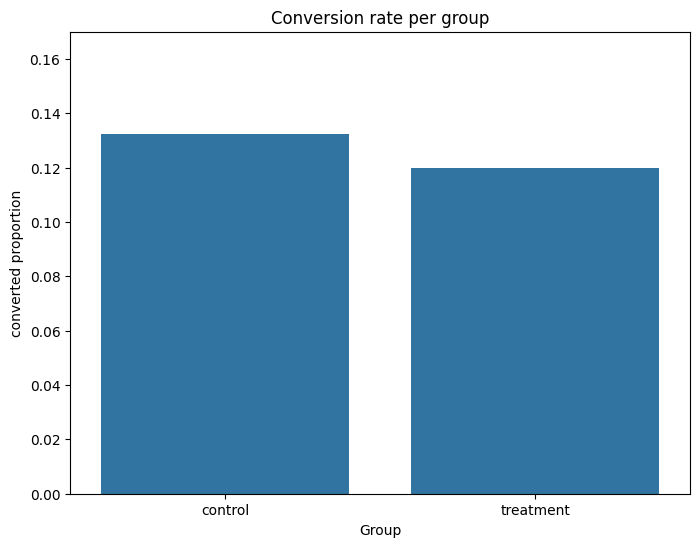

In [30]:
## visualize the differences

plt.figure(figsize =(8,6))

sns.barplot(x= ab_test["group"], y= ab_test["converted"], ci = False)

plt.ylim(0,0.17)
plt.title("Conversion rate per group")
plt.ylabel("converted proportion")
plt.xlabel("Group")

The conversion rates for our groups are indeed very close. Also note that the conversion rate of the `control` group is lower than what we would have expected given what we knew about our avg. conversion rate (12.3% vs. 13%). This goes to show that there is some variation in results when sampling from a population.

So... the `treatment` group's value is higher. **Is this difference *statistically significant***?

# 4. Testing the hypothesis

In [35]:
control_results = ab_test[ab_test["group"]== "control"]["converted"]
treatment_results = ab_test[ab_test["group"]== "treatment"]["converted"]

sms.ttest_ind(control_results, treatment_results)

(np.float64(1.8289945779441166),
 np.float64(0.06743195785273663),
 np.float64(9438.0))

In [ ]:
## Conclusion: within this scope, since the p value is bigger than 5% (significance level we fixed for our study),
## then we do not have evidence to reject the null hypothesis.